In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [ ]:
model = models.Sequential()

In [ ]:
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(layers.MaxPooling2D((2,2)))

In [ ]:
model.add(layers.Conv2D(64,(3,3),activation='relu'))

In [ ]:
model.add(layers.MaxPooling2D((2,2)))

In [ ]:
model.add(layers.Flatten())

In [ ]:
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9622 - loss: 0.1241 - val_accuracy: 0.9845 - val_loss: 0.0467
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9869 - loss: 0.0415 - val_accuracy: 0.9833 - val_loss: 0.0499
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.9913 - loss: 0.0278 - val_accuracy: 0.9891 - val_loss: 0.0339
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9934 - loss: 0.0208 - val_accuracy: 0.9896 - val_loss: 0.0314
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9951 - loss: 0.0151 - val_accuracy: 0.9918 - val_loss: 0.0293


In [ ]:
test_loss, test_acc = model.evaluate(x_test,y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9918 - loss: 0.0293
Test accuracy: 0.9918000102043152


In [ ]:
predictions = model.predict(x_test)

import numpy as np
print("Predicted:", np.argmax(predictions[0]))
print("Actual:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Predicted: 7
Actual: 7


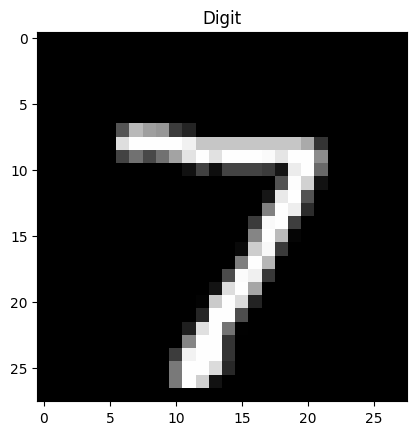

In [ ]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Digit")
plt.show()